In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import imageio
from datetime import datetime, timedelta
import geopandas as gpd
from shapely.geometry import Point
from esda.moran import Moran_Local
from libpysal.weights import Queen

data = pd.read_csv('../data/cleaned_2021-jan2025.csv')
data.dropna(subset=['Latitude', 'Longitude'])
data['IncidentDate'] = pd.to_datetime(data['IncidentDate'], format="mixed", dayfirst=False)

len(data)

# FILTER TO 2024
data = data[(data['IncidentDate'] >= '2024-01-01') & (data['IncidentDate'] < '2025-01-01')]

# --------------- CUT OUT POINTS OUTSIDE BOUNDARY

# Load the neighborhood shapefile
city_bounds = gpd.read_file('../data/city_bounds/stl_boundary.shp')


points = gpd.GeoDataFrame(data, geometry=gpd.points_from_xy(data.Longitude, data.Latitude))


# points = points.to_crs(city_bounds.crs)
points.set_crs(epsg=4326, inplace=True)

if city_bounds.crs != points.crs:
    points = points.to_crs(city_bounds.crs)

within_points = gpd.sjoin(points, city_bounds, how='inner', predicate = 'within')

columns_to_drop = ['index_right'] + list(city_bounds.columns)

within_points = within_points.drop(columns=columns_to_drop)

print(len(within_points))
data = within_points

# ------------------- NEIGHBORHOOD SHAPEFILE

neighborhoods = gpd.read_file('../data/neighborhoods/Neighborhoods.shp')


C:\Users\jz043x\AppData\Local\Temp\ipykernel_25848\2154753883.py:11: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('../data/cleaned_2021-jan2025.csv')


48915


In [2]:
neighborhood_pop = pd.read_csv('../data/neighborhoods/neighborhood_populations.csv')

In [3]:
data.head()

,IncidentDate,OccurredFromTime,IncidentNum,Offense,NIBRS,NIBRSCategory,SRS_UCR,CrimeAgainst,FelMisdCit,IncidentTopSRS_UCR,...,District,Neighborhood,NbhdNum,Latitude,Longitude,IncidentSupplemented,LastSuppDate,VictimNum,FirearmUsed,IncidentNature
12,2024-01-20,00:01:00,18055171,FAIL TO REGISTER AS A SEX OFFENDER PURSUANT TO...,90Z,All Other Offenses,NaN,Unspecified,F,NaN,...,4.0,Downtown West,36,38.63211,-90.207689,Yes,2024-05-31 13:08:43.000,NaN,No,Sex Offenses - Criminal
14,2024-01-20,00:01:00,18057715,FAIL TO REGISTER AS A SEX OFFENDER PURSUANT TO...,90Z,All Other Offenses,NaN,Unspecified,F,NaN,...,4.0,Downtown West,36,38.63211,-90.207689,Yes,2024-05-17 13:32:00.000,NaN,No,Sex Offenses - Criminal
15,2024-05-09,00:01:00,18058834,FAIL TO REGISTER AS A SEX OFFENDER PURSUANT TO...,90Z,All Other Offenses,NaN,Unspecified,F,NaN,...,4.0,Downtown West,36,38.63211,-90.207689,Yes,2024-05-17 12:44:30.000,NaN,No,Sex Offenses - Criminal
16,2024-01-20,00:01:00,18058867,FAIL TO REGISTER AS A SEX OFFENDER PURSUANT TO...,90Z,All Other Offenses,NaN,Unspecified,F,NaN,...,4.0,Downtown West,36,38.63211,-90.207689,Yes,2024-05-17 12:47:59.000,NaN,No,Sex Offenses - Criminal
17,2024-01-20,00:01:00,19000428,FAIL TO REGISTER AS A SEX OFFENDER PURSUANT TO...,90Z,All Other Offenses,NaN,Unspecified,F,NaN,...,4.0,Downtown West,36,38.63211,-90.207689,Yes,2024-05-17 12:41:14.000,NaN,No,Sex Offenses - Criminal


In [4]:
# Load the neighborhood shapefile
neighborhoods = gpd.read_file('../data/neighborhoods/Neighborhoods.shp')

# Aggregate crime data by neighborhood
crime_counts = data.groupby("Neighborhood")["IncidentNum"].count().reset_index(name="CrimeCount")

# Merge crime data with the shapefile
neighborhoods_with_crime = neighborhoods.merge(crime_counts, left_on="NHD_NAME", right_on="Neighborhood", how="left")
neighborhoods_with_crime = neighborhoods_with_crime.merge(neighborhood_pop, left_on="NHD_NAME", right_on="Neighborhood", how="left")
neighborhoods_with_crime["CrimeCount"] = neighborhoods_with_crime["CrimeCount"].fillna(0)
# neighborhoods_with_crime = neighborhoods_with_crime[~neighborhoods_with_crime['NHD_NAME'].isin(neighborhoods_to_drop)]
# neighborhoods_with_crime = neighborhoods_with_crime[neighborhoods_with_crime['Population'] >= 400]
neighborhoods_with_crime["PopCrime"] = neighborhoods_with_crime["CrimeCount"]/neighborhoods_with_crime["Population"]

# remove neighborhoods with less than 400 residents to not skew data
neighborhoods_with_crime['PopCrime'] = np.where(neighborhoods_with_crime['Population'] < 400, 0, neighborhoods_with_crime['PopCrime'])





In [5]:
neighborhoods_with_crime.head()

,NHD_NUM,NHD_NAME,ANGLE,NHD_NUMTXT,NHD_NUM_ST,geometry,Neighborhood_x,CrimeCount,Neighborhood_y,Population,PopCrime
0,43,Franz Park,0.0,43 Franz Park,None,"POLYGON ((877657.98 1016328.4, 877790.31 10162...",Franz Park,133.0,Franz Park,2260,0.058850
1,29,Tiffany,0.0,29 Tiffany,None,"POLYGON ((895417.85 1016887.24, 894894.99 1014...",Tiffany,236.0,Tiffany,915,0.257923
2,28,Botanical Heights,0.0,28 Botanical Heights,None,"POLYGON ((893871.83 1017297.51, 893519.4 10159...",Botanical Heights,169.0,Botanical Heights,1196,0.141304
3,40,Kings Oak,0.0,40 Kings Oak,None,"POLYGON ((887474.71 1017871.67, 887462.87 1017...",Kings Oak,72.0,Kings Oak,167,0.000000
4,41,Cheltenham,0.0,41 Cheltenham,None,"POLYGON ((884617.94 1018220.45, 884356.35 1016...",Cheltenham,249.0,Cheltenham,1260,0.197619


### Calculate Local Moran's I

C:\Users\jz043x\AppData\Local\Temp\ipykernel_25848\2375633957.py:7: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(neighborhoods_with_crime)
C:\Users\jz043x\AppData\Local\Programs\Python\Python311\Lib\site-packages\esda\moran.py:1350: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


('WARNING: ', 38, ' is an island (no neighbors)')


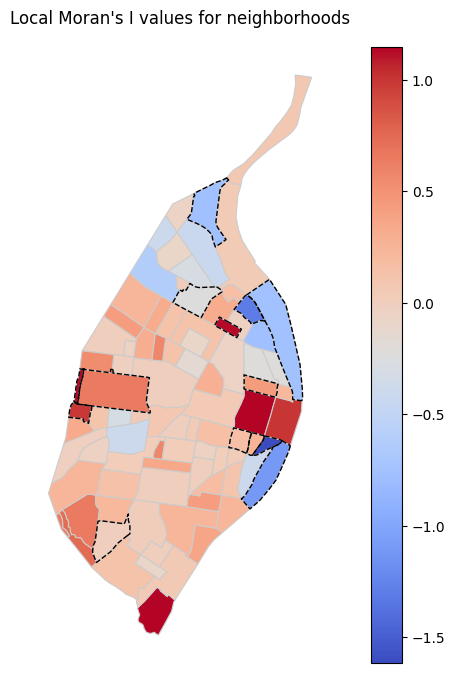

In [56]:
# Create a synthetic numerical attribute for each neighborhood (e.g., population or crime rate)
# Replace this with actual data if available
np.random.seed(42)  # For reproducibility
# neighborhoods_with_crime['PopCrime'] = np.random.randint(100, 1000, size=len(neighborhoods))

# Create a spatial weights matrix using Queen contiguity (neighbors touching)
w = Queen.from_dataframe(neighborhoods_with_crime)

# Calculate local Moran's I values
moran_local = Moran_Local(neighborhoods_with_crime['PopCrime'], w)

# Add the Moran's I values and p-values to the GeoDataFrame
neighborhoods['local_moran'] = moran_local.Is
neighborhoods['p_value'] = moran_local.p_sim

# Classify the neighborhoods into significant clusters at 0.05 significance level
neighborhoods['significant_cluster'] = moran_local.q
neighborhoods.loc[neighborhoods['p_value'] > 0.05, 'significant_cluster'] = 0

# Plot the neighborhoods with local Moran's I values
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
neighborhoods.plot(column='local_moran', cmap='coolwarm', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
ax.set_title('Local Moran\'s I values for neighborhoods')
ax.set_axis_off()

# Add a legend for significant clusters
significant_clusters = neighborhoods[neighborhoods['significant_cluster'] != 0]
significant_clusters.plot(ax=ax, color='none', edgecolor='black', linewidth=1, linestyle='--')

# Show the plot
plt.show()

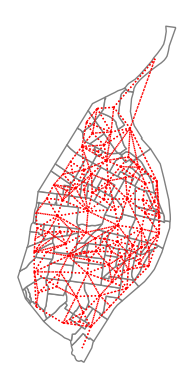

In [59]:
ax = neighborhoods.plot(edgecolor='grey', facecolor='w')
f,ax = w.plot(neighborhoods, ax=ax, 
        edge_kws=dict(color='r', linestyle=':', linewidth=1),
        node_kws=dict(marker=''))
ax.set_axis_off()

In [9]:
neighborhoods.iloc[87]

NHD_NUM                                                               35
NHD_NAME                                                        Downtown
ANGLE                                                                0.0
NHD_NUMTXT                                                   35 Downtown
NHD_NUM_ST                                                          None
geometry               POLYGON ((909874.5001238286 1020004.6001509055...
local_moran                                                     1.006409
p_value                                                            0.176
significant_cluster                                                    0
Name: 87, dtype: object

In [10]:
neighbors_touching = neighborhoods[neighborhoods.geometry.touches(neighborhoods.iloc[87].geometry)]['NHD_NAME'].tolist()
neighbors_touching

['Downtown West',
 'Columbus Square',
 'Carr Square',
 'Kosciusko',
 'LaSalle Park',
 'Peabody Darst Webbe',
 'Near North Riverfront']

In [11]:
# Load the neighborhood shapefile
neighborhoods= gpd.read_file('../data/neighborhoods/Neighborhoods.shp')

neighborhoods['buffered_geometry'] = neighborhoods.geometry.buffer(10)

# neighborhoods_buff.head()

In [12]:
nbhd = neighborhoods.iloc[38]

neighbors_almost_touching = neighborhoods[neighborhoods['buffered_geometry'].intersects(nbhd.geometry) & (neighborhoods.index != nbhd.name)]

neighbors_almost_touching

,NHD_NUM,NHD_NAME,ANGLE,NHD_NUMTXT,NHD_NUM_ST,geometry,buffered_geometry
36,4,Boulevard Heights,0.0,4 Boulevard Heights,None,"POLYGON ((886035.2 995663.35, 886027.7 995625....","POLYGON ((886029.956 995671.864, 886030.801 99..."
39,8,St. Louis Hills,0.0,8 St. Louis Hills,None,"MULTIPOLYGON (((879009.31 1004978.19, 878976.1...","MULTIPOLYGON (((879010.525 1004988.116, 879011..."
40,88,Willmore Park,0.0,88 Willmore Park,None,"POLYGON ((878482.08 996448.52, 878464.99 99633...","POLYGON ((878488.135 996456.479, 878488.882 99..."
42,5,Bevo Mill,0.0,5 Bevo Mill,None,"POLYGON ((888886.11 1003744.17, 888894.61 1003...","POLYGON ((888887.335 1003754.095, 888888.306 1..."
43,7,Southampton,0.0,7 Southampton,None,"POLYGON ((884994.689 1004280.739, 884188.16 10...","POLYGON ((884996.27 1004290.613, 884997.252 10..."


In [13]:
neighborhoods= gpd.read_file('../data/neighborhoods/Neighborhoods.shp')

neighborhoods['buffered_geometry'] = neighborhoods.geometry.buffer(10)

# Create an empty dictionary to store neighboring counties
nbhd_neighbors = {}

# Loop over each county to find its neighbors
for idx, neighborhood in neighborhoods.iterrows():
    neighborhood_name = neighborhood['NHD_NAME']

    # Get neighboring counties based on different geometric relationships
    # 1. Counties that touch the edges of the current county
    neighbors = neighborhoods[neighborhoods['buffered_geometry'].intersects(neighborhood.geometry)]

    if idx == 38:
        print(neighbors)

    # Remove the county itself from the neighbors list
    neighbors = neighbors[neighbors['NHD_NAME'] != neighborhood_name]

    
    # Store the neighboring counties in the dictionary
    nbhd_neighbors[neighborhood_name] = neighbors['NHD_NAME'].tolist()

    NHD_NUM           NHD_NAME  ANGLE           NHD_NUMTXT NHD_NUM_ST  \
36        4  Boulevard Heights    0.0  4 Boulevard Heights       None   
38        6  Princeton Heights    0.0  6 Princeton Heights       None   
39        8    St. Louis Hills    0.0    8 St. Louis Hills       None   
40       88      Willmore Park    0.0     88 Willmore Park       None   
42        5          Bevo Mill    0.0          5 Bevo Mill       None   
43        7        Southampton    0.0        7 Southampton       None   

                                             geometry  \
36  POLYGON ((886035.2 995663.35, 886027.7 995625....   
38  POLYGON ((883927.277 998619.238, 883913.857 99...   
39  MULTIPOLYGON (((879009.31 1004978.19, 878976.1...   
40  POLYGON ((878482.08 996448.52, 878464.99 99633...   
42  POLYGON ((888886.11 1003744.17, 888894.61 1003...   
43  POLYGON ((884994.689 1004280.739, 884188.16 10...   

                                    buffered_geometry  
36  POLYGON ((886029.956 995671.

In [14]:
nbhd_neighbors

{'Franz Park': ['Clayton-Tamm', 'Hi-Pointe', 'Ellendale'],
 'Tiffany': ['Botanical Heights',
  'Midtown',
  'Compton Heights',
  'Shaw',
  'The Gate District'],
 'Botanical Heights': ['Tiffany',
  'Forest Park South East',
  'Midtown',
  'Shaw',
  'Southwest Garden'],
 'Kings Oak': ['Cheltenham',
  'Forest Park South East',
  'The Hill',
  'Forest Park'],
 'Cheltenham': ['Kings Oak',
  'Clayton-Tamm',
  'Ellendale',
  'The Hill',
  'Forest Park'],
 'Clayton-Tamm': ['Franz Park',
  'Cheltenham',
  'Hi-Pointe',
  'Ellendale',
  'The Hill',
  'Forest Park'],
 'Forest Park South East': ['Botanical Heights',
  'Kings Oak',
  'Midtown',
  'Central West End',
  'Southwest Garden',
  'The Hill',
  'Forest Park'],
 'Hi-Pointe': ['Franz Park', 'Clayton-Tamm', 'Wydown Skinker', 'Forest Park'],
 'Downtown West': ['Midtown',
  'Carr Square',
  'Jeff Vanderlou',
  'LaSalle Park',
  'Peabody Darst Webbe',
  'Lafayette Square',
  'The Gate District',
  'Downtown'],
 'Midtown': ['Tiffany',
  'Botanical

In [15]:
# Get the list of all counties
neighborhood_names = list(nbhd_neighbors.keys())


In [16]:
# Initialize an empty DataFrame with counties as both rows and columns
adjacency_matrix = pd.DataFrame(index=neighborhood_names, columns=neighborhood_names)

# Fill the DataFrame
for nbhd in neighborhood_names:
    for neighb in adjacency_matrix:
        if neighb in nbhd_neighbors[nbhd]:
            adjacency_matrix.at[nbhd, neighb] = 1
        else:
            adjacency_matrix.at[nbhd, neighb] = 0

In [17]:
adjacency_matrix

,Franz Park,Tiffany,Botanical Heights,Kings Oak,Cheltenham,Clayton-Tamm,Forest Park South East,Hi-Pointe,Downtown West,Midtown,...,Bellefontaine/Calvary Cemetery,Walnut Park West,North Pointe,North Riverfront,Baden,Riverview,Forest Park,DeBaliviere Place,Skinker DeBaliviere,Downtown
Franz Park,0,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
Tiffany,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
Botanical Heights,0,1,0,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
Kings Oak,0,0,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
Cheltenham,0,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Riverview,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,0
Forest Park,0,0,0,1,1,1,1,1,0,0,...,0,0,0,0,0,0,0,1,1,0
DeBaliviere Place,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
Skinker DeBaliviere,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,0


In [18]:
neighborhood_pop = pd.read_csv('../data/neighborhoods/neighborhood_populations.csv')

# Aggregate crime data by neighborhood
crime_counts = data.groupby("Neighborhood")["IncidentNum"].count().reset_index(name="CrimeCount")

# Merge crime data with the shapefile
neighborhoods = neighborhoods.merge(crime_counts, left_on="NHD_NAME", right_on="Neighborhood", how="left")
neighborhoods = neighborhoods.merge(neighborhood_pop, left_on="NHD_NAME", right_on="Neighborhood", how="left")
neighborhoods["CrimeCount"] = neighborhoods["CrimeCount"].fillna(0)
# neighborhoods_with_crime = neighborhoods_with_crime[~neighborhoods_with_crime['NHD_NAME'].isin(neighborhoods_to_drop)]
# neighborhoods_with_crime = neighborhoods_with_crime[neighborhoods_with_crime['Population'] >= 400]
neighborhoods["PopCrime"] = neighborhoods["CrimeCount"]/neighborhoods["Population"]

# remove neighborhoods with less than 400 residents to not skew data
# neighborhoods['PopCrime'] = np.where(neighborhoods['Population'] < 400, 0, neighborhoods['PopCrime'])

In [22]:
# neighborhoods["PopCrime"].describe()
# print(neighborhoods.sort_values(by='PopCrime', ascending=False)[:15])
#neighborhoods[(neighborhoods['PopCrime'] - neighborhoods['PopCrime'].mean()).abs() > 2 * neighborhoods['PopCrime'].std()]

# neighborhoods["Park" in neighborhoods['NHD_NAME']]
neighborhoods[neighborhoods['NHD_NAME'].str.contains('Park')]

,NHD_NUM,NHD_NAME,ANGLE,NHD_NUMTXT,NHD_NUM_ST,geometry,buffered_geometry,Neighborhood_x,CrimeCount,Neighborhood_y,Population,PopCrime
0,43,Franz Park,0.0,43 Franz Park,None,"POLYGON ((877657.98 1016328.4, 877790.31 10162...","POLYGON ((877661.904 1016337.598, 877662.985 1...",Franz Park,133.0,Franz Park,2260,0.058850
6,39,Forest Park South East,0.0,39 Forest Park South East,None,"POLYGON ((893537.76 1019073.79, 893500.5 10190...","POLYGON ((893547.259 1019070.663, 893546.944 1...",NaN,0.0,Forest Park South East,3458,0.000000
18,49,Visitation Park,0.0,49 Visitation Park,None,"POLYGON ((885247.62 1029086.31, 884927.93 1026...","POLYGON ((885248.884 1029096.23, 885249.85 102...",Visitation Park,87.0,Visitation Park,924,0.094156
20,53,Fountain Park,0.0,53 Fountain Park,None,"POLYGON ((889914.81 1029665.53, 889439.12 1026...","POLYGON ((889918.795 1029674.702, 889919.684 1...",Fountain Park,250.0,Fountain Park,1075,0.232558
24,65,Hyde Park,0.0,65 Hyde Park,None,"POLYGON ((905531.47 1032322.28, 905623.46 1032...","POLYGON ((905532.36 1032332.24, 905533.341 103...",Hyde Park,591.0,Hyde Park,2271,0.260238
25,83,Fairground Park,0.0,83 Fairground Park,None,"POLYGON ((899571.16 1032268.52, 900621.09 1031...","POLYGON ((899575.997 1032277.272, 900625.915 1...",Fairground Park,38.0,Fairground Park,12,3.166667
33,80,Carondelet Park,0.0,80 Carondelet Park,None,"POLYGON ((888932.37 993728.15, 888950.12 99372...","POLYGON ((888936.109 993737.573, 888952.235 99...",Carondelet Park,48.0,Carondelet Park,15,3.200000
40,88,Willmore Park,0.0,88 Willmore Park,None,"POLYGON ((878482.08 996448.52, 878464.99 99633...","POLYGON ((878488.135 996456.479, 878488.882 99...",Willmore Park,47.0,Willmore Park,1,47.000000
45,19,Gravois Park,0.0,19 Gravois Park,None,"POLYGON ((898673.03 1004985.91, 898262.09 1002...","POLYGON ((898674.584 1004995.789, 898675.545 1...",Gravois Park,1197.0,Gravois Park,4683,0.255605
47,30,Benton Park West,0.0,30 Benton Park West,None,"POLYGON ((898673.03 1004985.91, 895411.42 1005...","POLYGON ((898682.902 1004984.312, 898682.698 1...",Benton Park West,680.0,Benton Park West,4238,0.160453


In [61]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    print(neighborhoods)


    NHD_NUM                        NHD_NAME  ANGLE  \
0        43                      Franz Park    0.0   
1        29                         Tiffany    0.0   
2        28               Botanical Heights    0.0   
3        40                       Kings Oak    0.0   
4        41                      Cheltenham    0.0   
5        42                    Clayton-Tamm    0.0   
6        39          Forest Park South East    0.0   
7        44                       Hi-Pointe    0.0   
8        36                   Downtown West    0.0   
9        37                         Midtown    0.0   
10       62                 Columbus Square    0.0   
11       61                     Carr Square    0.0   
12       45                  Wydown Skinker    0.0   
13       77       Covenant Blu-Grand Center    0.0   
14       38                Central West End    0.0   
15       63             Old North St. Louis    0.0   
16       58                     Vandeventer    0.0   
17       60                 

In [40]:

N = len(neighborhoods)
W = adjacency_matrix.sum().sum()

rates = neighborhoods.set_index('NHD_NAME')['PopCrime'].fillna(0)
mean_rate = rates.mean()
local_moran_I = pd.Series(index=neighborhoods)

for i in neighborhood_names:
    # Calculate the weighted sum for neighbors
    sum_weights = 0
    for j in neighborhood_names:
        sum_weights += adjacency_matrix.at[i, j] * (rates[j] - mean_rate)
    
    # Local Moran's I formula (to measure the impact from each county)
    local_moran_I[i] = N * (rates[i] - mean_rate) * sum_weights / W

denominator = ((rates - mean_rate) ** 2).sum()
local_moran_I = local_moran_I / denominator

print(f"Moran's I: {local_moran_I.sum()}")

Moran's I: -0.02337514981185462


In [50]:
for x in neighborhood_names:
    print(x)
    print(local_moran_I[x])

Franz Park
0.00022322525225499163
Tiffany
0.0002770286721847437
Botanical Heights
0.00031841237827370496
Kings Oak
-0.0001814849327634796
Cheltenham
-0.0002044593092299815
Clayton-Tamm
-0.00015551531200298167
Forest Park South East
-0.00011577632100218074
Hi-Pointe
-0.00027660443289966345
Downtown West
0.00032379751593164725
Midtown
0.000561360206998065
Columbus Square
0.00020407143769704674
Carr Square
0.00033590633969318153
Wydown Skinker
-0.0003541716323822056
Covenant Blu-Grand Center
0.0003778667628237105
Central West End
0.00012203676986782171
Old North St. Louis
0.0002637519301953169
Vandeventer
0.00038454065687425497
St. Louis Place
0.0003583281162161075
Visitation Park
0.0002614369701145537
Lewis Place
0.0003623735487210128
Fountain Park
0.00027021156915713333
Jeff Vanderlou
0.00048515175664355143
The Ville
0.000178136856790379
Academy
0.000517843675341899
Hyde Park
0.00028179535196205097
Fairground Park
-0.0006492400299049935
West End
0.000325108356773905
Greater Ville
0.0004

In [54]:
max(local_moran_I.values)

nan